In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"dataset\student_productivity_distraction_dataset_20000.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  object 
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  fo

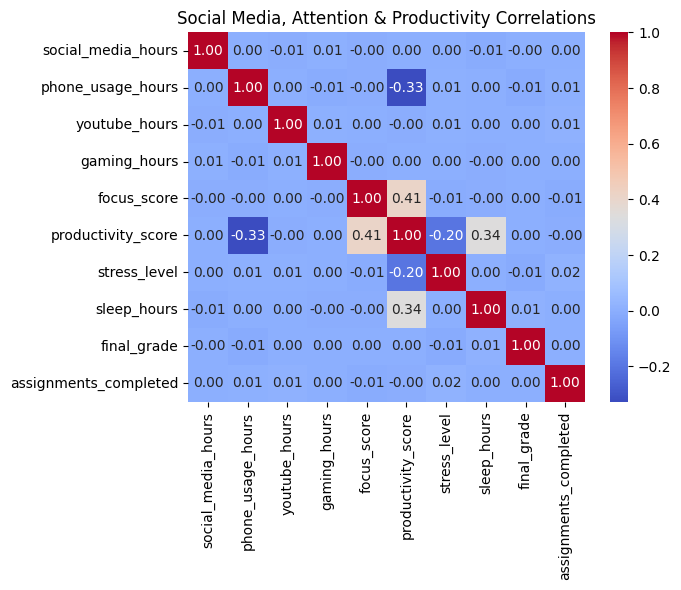

In [3]:
cols = ['social_media_hours', 'phone_usage_hours', 'youtube_hours',
        'gaming_hours', 'focus_score', 'productivity_score',
        'stress_level', 'sleep_hours', 'final_grade',
        'assignments_completed']

sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Social Media, Attention & Productivity Correlations')
plt.show()

                    total_screen_time  focus_score  productivity_score
total_screen_time                1.00         0.00               -0.23
focus_score                      0.00         1.00                0.41
productivity_score              -0.23         0.41                1.00


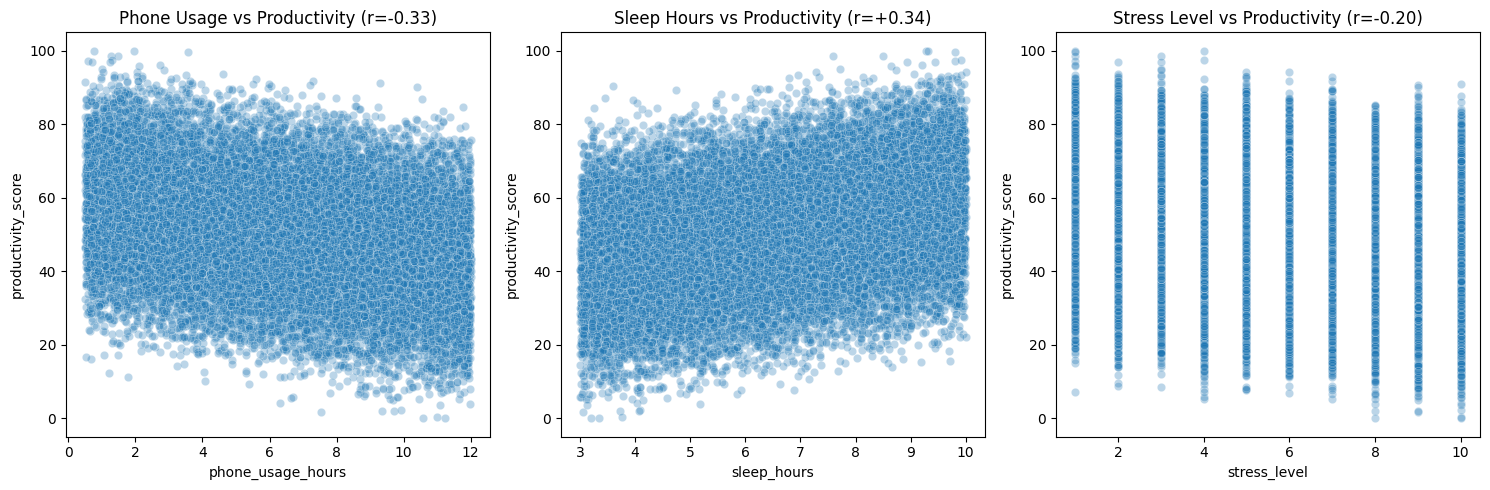

In [5]:
# 1. Check if total screen time (combined) has more impact
df['total_screen_time'] = (df['social_media_hours'] + 
                                   df['phone_usage_hours'] +
                                   df['youtube_hours'] + 
                                   df['gaming_hours'])

print(df[['total_screen_time', 'focus_score', 
                  'productivity_score']].corr().round(2))

# 2. Visualize the strongest relationships you found
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.scatterplot(data=df, x='phone_usage_hours', 
                y='productivity_score', alpha=0.3, ax=axes[0])
axes[0].set_title('Phone Usage vs Productivity (r=-0.33)')

sns.scatterplot(data=df, x='sleep_hours', 
                y='productivity_score', alpha=0.3, ax=axes[1])
axes[1].set_title('Sleep Hours vs Productivity (r=+0.34)')

sns.scatterplot(data=df, x='stress_level', 
                y='productivity_score', alpha=0.3, ax=axes[2])
axes[2].set_title('Stress Level vs Productivity (r=-0.20)')

plt.tight_layout()
plt.show()